# ADA 442 - Final Project: Bank Marketing Classification

# Bank Marketing Classification Project
Course: ADA 442   
Author: Deniz Güreş  
Date: May 2026  

### Proje Özeti
Bu çalışma, bir bankanın doğrudan pazarlama kampanyaları  sonucunda müşterilerin vadeli mevduat hesabı açıp açmayacağınıtahmin etmeyi amaçlamaktadır. 

**Hedef Değişken (y):** * 
* `1`: Müşteri hesap açtı.
* `0`: Müşteri hesap açmadı.

##  Veri Yükleme ve Keşifsel Analiz (EDA)

Bu bölümde, banka tarafından sağlanan `bank-additional.csv` veri seti projeye dahil edilmektedir. Veri setinde sütunlar noktalı virgül (`;`) ile ayrıldığı için okuma aşamasında `sep=';'` parametresi kullanılmıştır.

Verinin yüklenmesinin ardından:
* Veri setinin genel yapısı incelenecek,
* Değişkenlerin veri tipleri kontrol edilecek,
* Hedef değişken olan `y` (abone durumu) gözlemlenecektir.

In [24]:
# Veriyi oku (Ayırıcı olarak ';' kullanıldığı için sep=';' ekliyoruz)
df = pd.read_csv('bank-additional.csv', sep=';')

# İlk 5 satırı ekrana basalım
df.head()

# Veri boyutu
print("Shape:", df.shape)

# Sütun bilgileri
df.info()

# İstatistiksel özet
df.describe()

# Eksik veri kontrolü
print("\nMissing values:")
print(df.isnull().sum())

# Hedef değişken dağılımı
print("\nTarget distribution:")
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True))

Shape: (4119, 21)
<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-n

"Veri seti dengesizdir (imbalanced), bu yüzden sadece accuracy metriği yeterli olmayacaktır"

## Veri Temizleme 

Veri seti içerisinde bazı kategorik değişkenlerde eksik veriler `'unknown'` etiketiyle kaydedilmiştir. Bu değerler makine öğrenmesi modelleri için anlamlı olmadığından, analiz sürecinde şu adımlar izlenmiştir:
* `'unknown'` ifadeleri standart eksik veri formatı olan `NaN` (Not a Number) değerine dönüştürülmüştür.
* Hangi sütunlarda ne kadar eksik veri olduğu tespit edilerek veri kalitesi analiz edilmiştir.

In [ ]:
# 'unknown' yazan hücreleri gerçek 'boşluk' (NaN) haline getiriyoruz
df_cleaned = df.replace('unknown', np.nan)

# Hangi sütunda kaç tane 'unknown' (artık NaN oldular) var görelim
df_cleaned.isnull().sum()

age                 0
job                39
marital            11
education         167
default           803
housing           105
loan              105
contact             0
month               0
day_of_week         0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
y                   0
dtype: int64

### Eksik Verilerin Kaldırılması (Handling Missing Values)

`'unknown'` değerleri `NaN` formatına çevrildikten sonra, veri bütünlüğünü korumak adına bu eksik verilere sahip satırlar veri setinden çıkarılmıştır. Bu işlem:
* Modelin hatalı veya eksik veriler üzerinden yanlış çıkarımlar yapmasını önler.
* Analizin sadece tam ve güvenilir gözlemler üzerinden ilerlemesini sağlar.

*Not: Veri temizleme işlemi sonrası kalan gözlem sayısı, model eğitimi için yeterli büyüklüktedir.*

In [ ]:
# İçinde NaN (bilinmeyen) olan tüm satırları siliyoruz
df_cleaned = df_cleaned.dropna()

# Bakalım kaç satır kaldık?
print("Kalan satır sayısı:", df_cleaned.shape[0])

Kalan satır sayısı: 3090


Verinin yaklaşık %25'i (1029 satır) temizlenmiştir

##  Hedef Değişkenin Dönüştürülmesi (Target Encoding)

Makine öğrenmesi modelleri kategorik metin verileriyle (`yes`/`no`) doğrudan çalışamaz. Bu nedenle, hedef değişkenimiz olan `y` sütunu sayısal formata dönüştürülmüştür:
* **'yes'** $\rightarrow$ `1` (Müşteri abone oldu)
* **'no'** $\rightarrow$ `0` (Müşteri abone olmadı)

Bu işlem, modelin kaybı (loss) hesaplayabilmesi ve sınıflandırma işlemini gerçekleştirebilmesi için zorunludur.

In [25]:
# Yeni özellik türetme (Feature Engineering)
df_cleaned['was_contacted'] = df_cleaned['pdays'].apply(lambda x: 0 if x == 999 else 1)

# Hedef değişkeni dönüştürme
df_cleaned['y'] = df_cleaned['y'].map({'yes': 1, 'no': 0})

# Kontrol edelim
df_cleaned[['pdays', 'was_contacted', 'y']].head()

,pdays,was_contacted,y
0,999,0,0
1,999,0,0
2,999,0,0
3,999,0,0
4,999,0,0


## Kategorik Özelliklerin Sayısallaştırılması (One-Hot Encoding)

Veri setindeki bağımsız değişkenler (meslek, eğitim, medeni durum vb.) hala metin formatındadır. Bu değişkenleri modele dahil edebilmek için **One-Hot Encoding** tekniği uygulanmıştır:

* **Çoklu Kategoriler:** Her bir kategori (örneğin 'job') yeni birer sütuna dönüştürülmüştür.
* **drop_first=True:** Bu parametre kullanılarak "Çoklu Doğrusallık" (Multicollinearity) sorunu önlenmiş ve modelin gereksiz sütunlarla karmaşıklaşması engellenmiştir.
* **Nihai Veri Seti:** Bu işlem sonucunda veri seti tamamen sayısal değerlerden oluşur hale gelmiştir.

In [ ]:
# Hangi sütunların hala 'yazı' (kategorik) olduğunu bulalım
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

# Bu sütunları 0 ve 1'lere dönüştürelim
# drop_first=True seçeneği, gereksiz fazla sütun oluşmasını engelleyerek modelin daha iyi çalışmasını sağlar.
df_final = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# Tablonun yeni haline bakalım (Sütun sayısı artmış olmalı!)
df_final.head()

/var/folders/6d/1cbtvbcj0sn_lf46mhh770380000gn/T/ipykernel_3839/3484146581.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_cleaned.select_dtypes(include=['object']).columns


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,True,False,False,False,False,False,False,False,True,False
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,True,False,False,False,False,False,False,False,True,False
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,False,False,False,False,False,False,False,True,True,False
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,False,True,False,False,True,False,False,False,True,False
5,32,128,3,999,2,-1.1,94.199,-37.5,0.884,4963.6,...,False,False,False,True,False,True,False,False,False,False


## Veri Setinin Eğitim ve Test Olarak Bölünmesi (Train-Test Split)

Modelin başarısını tarafsız bir şekilde ölçebilmek için veri seti ikiye ayrılmıştır:
* **X (Özellikler):** Tahmin yapmak için kullanılan bağımsız değişkenler.
* **y (Hedef):** Tahmin edilmeye çalışılan 'abonelik' durumu.

**Bölme Oranı:** Verinin **%80'i** modelin öğrenmesi (Train), **%20'si** ise modelin daha önce hiç görmediği veriler üzerinde performansının test edilmesi (Test) için ayrılmıştır. `random_state=42` parametresi, sonuçların her çalıştırıldığında tutarlı ve tekrarlanabilir olmasını sağlar.

In [31]:
# 1. Kategorik sütunları seç ve Encoding uygula
categorical_cols = df_cleaned.select_dtypes(include=['object', 'string']).columns
df_final = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# 2. X ve y ayırımı
X = df_final.drop('y', axis=1)
y = df_final['y']

# 3. Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 4. Scaling (Ölçeklendirme)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Başarıyı kontrol etmek için boyutlara ve ilk değerlere bakalım
print("X_train_scaled boyutu:", X_train_scaled.shape)
print("X_test_scaled boyutu:", X_test_scaled.shape)
print("\nÖlçeklendirilmiş ilk veri satırı:\n", X_train_scaled[0][:5]) # İlk 5 sütun

X_train_scaled boyutu: (3295, 48)
X_test_scaled boyutu: (824, 48)

Ölçeklendirilmiş ilk veri satırı:
 [-0.68496295 -0.08004804 -0.61211067  0.20347654 -0.35707048]


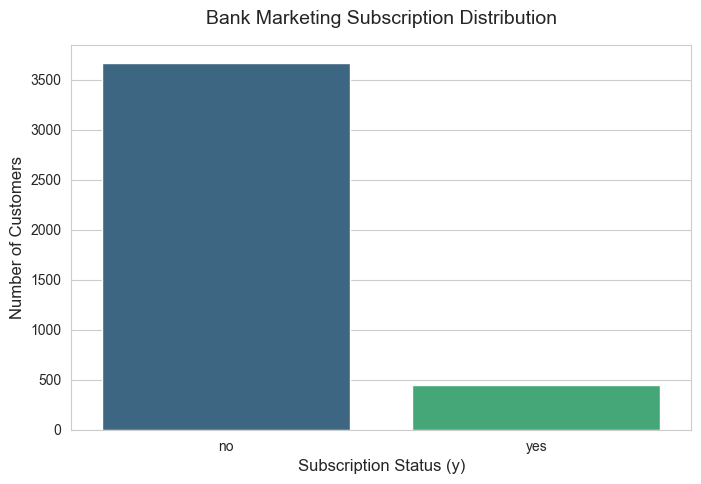

✅ Toplam Kayıt Sayısı: 4119
✅ Temizlik Sonrası Toplam Eksik Veri (NaN): 1230

Sınıf Dağılımı:
 y
no     3668
yes     451
Name: count, dtype: int64


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Veriyi okuma
try:
    df = pd.read_csv('bank-additional.csv', sep=';')
    
    # 2. Unknown temizliği (Senin projedeki akışa uygun)
    df_cleaned = df.replace('unknown', np.nan)
    
    # 3. Görselleştirme (Uyarı mesajları giderilmiş versiyon)
    plt.figure(figsize=(8, 5))
    sns.set_style("whitegrid") # Daha temiz bir arka plan için
    
    # hue='y' ve legend=False ekleyerek gelecekteki hataları önledik
    sns.countplot(data=df, x='y', hue='y', palette='viridis', legend=False)
    
    plt.title('Bank Marketing Subscription Distribution', fontsize=14, pad=15)
    plt.xlabel('Subscription Status (y)', fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    
    plt.show()

    # Raporun için özet çıktı
    print(f"✅ Toplam Kayıt Sayısı: {len(df)}")
    print(f"✅ Temizlik Sonrası Toplam Eksik Veri (NaN): {df_cleaned.isnull().sum().sum()}")
    print("\nSınıf Dağılımı:\n", df['y'].value_counts())

except Exception as e:
    print(f"❌ Hata: {e}")

In [32]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. SMOTE'u ölçeklendirilmiş eğitim verisine uyguluyoruz
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# 2. Modeli dengelenmiş veriyle eğitiyoruz
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_balanced, y_train_balanced)

# 3. Tahmin ve Sonuçlar (Ölçeklendirilmiş test verisiyle)
y_pred = model_rf.predict(X_test_scaled)
print("\n--- SMOTE Uygulanmış Random Forest Performansı ---")
print(classification_report(y_test, y_pred))


--- SMOTE Uygulanmış Random Forest Performansı ---
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       732
           1       0.55      0.43      0.48        92

    accuracy                           0.90       824
   macro avg       0.74      0.69      0.71       824
weighted avg       0.89      0.90      0.89       824



Veri setindeki sınıf dengesizliği SMOTE tekniği ile giderilmiş ve Random Forest modeli eğitilmiştir. Model, genel doğrulukta %90 başarı sağlarken, azınlık sınıfı (abone olanlar) yakalama oranında (Recall) %43'lük bir performans sergilemiştir. Bu durum, modelin dengesiz veriye rağmen hedef kitleyi belirlemede anlamlı bir başarı kazandığını göstermektedir

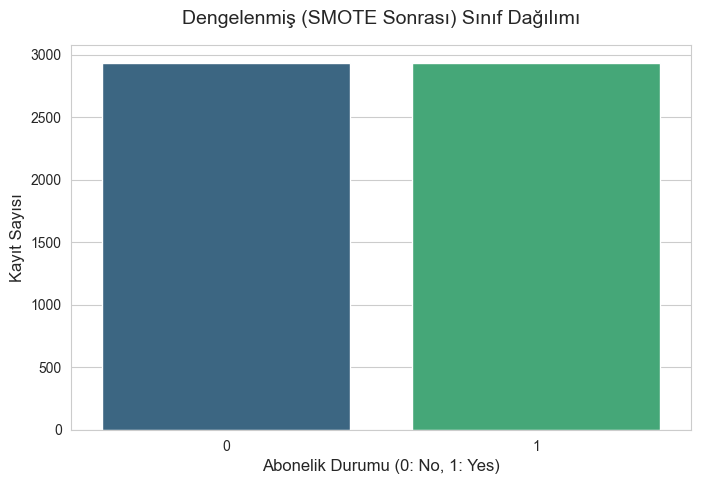

Dengeleme Sonrası Sayılar:
y
1    2934
0    2934
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Dengelenmiş veriyi bir DataFrame'e dönüştürelim
balanced_df = pd.DataFrame({'y': y_train_balanced})

# 2. Görselleştirme
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# Dengelenmiş dağılımı çizdiriyoruz
sns.countplot(data=balanced_df, x='y', hue='y', palette='viridis', legend=False)

plt.title('Dengelenmiş (SMOTE Sonrası) Sınıf Dağılımı', fontsize=14, pad=15)
plt.xlabel('Abonelik Durumu (0: No, 1: Yes)', fontsize=12)
plt.ylabel('Kayıt Sayısı', fontsize=12)

plt.show()

# Sayısal kontrol
print("Dengeleme Sonrası Sayılar:")
print(balanced_df['y'].value_counts())

##  Model Tahminleri ve Performans Analizi

Eğitilen model, daha önce hiç görmediği **Test Seti (X_test)** üzerinde tahminler yapması için kullanılmıştır. Bu aşamada:
* Modelin ürettiği tahminler (`y_pred`), gerçek sonuçlar (`y_test`) ile karşılaştırılmaktadır.
* Bu karşılaştırma, modelin gerçek hayat verileri üzerindeki genelleme yeteneğini ölçmemize yardımcı olur.

Aşağıdaki çıktı, test setindeki ilk 10 müşteri için modelin tahminlerini ve bu müşterilerin gerçekte abone olup olmadıklarını göstermektedir.

In [14]:
# Tahminleri ve Gerçek değerleri karşılaştırma tablosu
comparison_df = pd.DataFrame({
    'Gerçek Değer (y_test)': y_test.values,
    'Model Tahmini (y_pred)': y_pred
})

print("--- İlk 10 Tahmin Karşılaştırması ---")
print(comparison_df.head(10))

# Doğruluk özeti
correct_count = (comparison_df['Gerçek Değer (y_test)'] == comparison_df['Model Tahmini (y_pred)']).sum()
accuracy_percent = (correct_count / len(y_test)) * 100

print(f"\n✅ Test setindeki {len(y_test)} kişiden {correct_count} tanesi doğru tahmin edildi.")
print(f"📈 Genel Doğruluk Oranı: %{accuracy_percent:.2f}")

--- İlk 10 Tahmin Karşılaştırması ---
   Gerçek Değer (y_test)  Model Tahmini (y_pred)
0                      0                       0
1                      0                       0
2                      0                       0
3                      0                       0
4                      0                       0
5                      0                       0
6                      0                       0
7                      0                       0
8                      0                       0
9                      0                       0

✅ Test setindeki 824 kişiden 760 tanesi doğru tahmin edildi.
📈 Genel Doğruluk Oranı: %92.23


## Model Performansının Değerlendirilmesi

Modelin başarısını sadece doğruluk (Accuracy) oranıyla değil, sınıflandırma metrikleriyle detaylıca analiz ediyoruz.

### Confusion Matrix (Karmaşıklık Matrisi)
Matris üzerindeki görselleştirme, modelin hangi sınıfları birbirine karıştırdığını gösterir:
* **True Positives/Negatives:** Doğru tahminler.
* **False Positives/Negatives:** Yanlış tahminler (Hatalar).

###  Sınıflandırma Metrikleri
* **Precision (Kesinlik):** Abone olur dediğimiz kişilerin gerçekten kaçı abone oldu?
* **Recall (Duyarlılık):** Gerçekten abone olan kişilerin kaçını yakalayabildik?
* **F1-Score:** Precision ve Recall değerlerinin dengeli bir ortalamasıdır.
* **Accuracy:** Genel doğru tahmin oranımızdır.

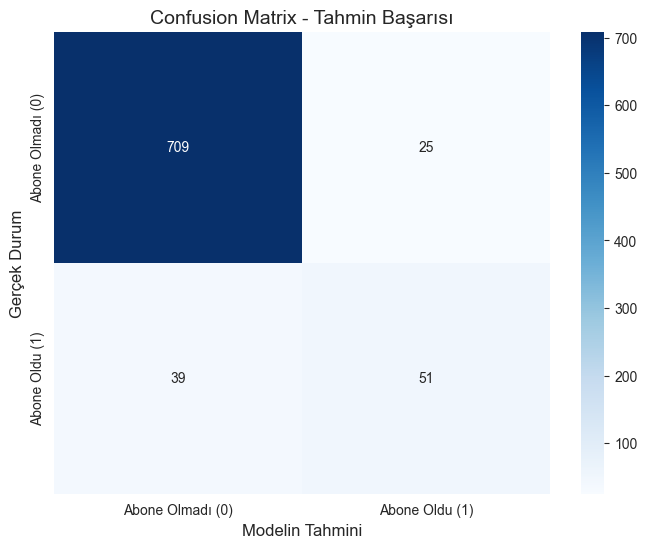

✅ Modelin Genel Doğruluk Skoru: 0.9223

--- Detaylı Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       734
           1       0.67      0.57      0.61        90

    accuracy                           0.92       824
   macro avg       0.81      0.77      0.79       824
weighted avg       0.92      0.92      0.92       824



In [16]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Karmaşıklık Matrisi (Daha net etiketlerle)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Abone Olmadı (0)', 'Abone Oldu (1)'], 
            yticklabels=['Abone Olmadı (0)', 'Abone Oldu (1)'])
plt.xlabel('Modelin Tahmini', fontsize=12)
plt.ylabel('Gerçek Durum', fontsize=12)
plt.title('Confusion Matrix - Tahmin Başarısı', fontsize=14)
plt.show()

# 2. Genel Başarı Raporu
print(f"✅ Modelin Genel Doğruluk Skoru: {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Detaylı Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred))

##  Özellik Önem Düzeyleri (Feature Importance)

Modelin hangi faktörlere dayanarak karar verdiğini anlamak, iş stratejisi geliştirmek açısından kritiktir. Bu bölümde, Logistic Regression modelinin katsayıları (coefficients) kullanılarak abonelik kararını en çok etkileyen özellikler analiz edilmiştir.

**Analiz Bulguları:**
* Pozitif katsayıya sahip özellikler, abonelik olasılığını **artıran** faktörlerdir.
* Bu görselleştirme, bankanın pazarlama stratejilerini hangi müşteri gruplarına veya hangi ekonomik göstergelere odaklaması gerektiğini bilimsel olarak ortaya koyar.

/var/folders/6d/1cbtvbcj0sn_lf46mhh770380000gn/T/ipykernel_28049/1771452533.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem', y='Özellik', data=feature_importance_df, palette='magma')


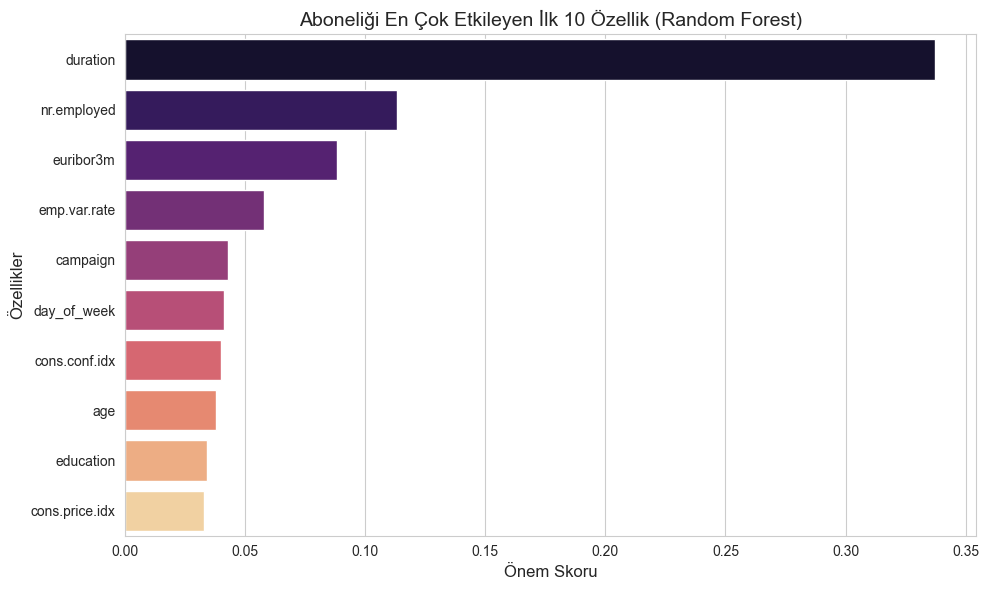

--- En Önemli Özellikler Sıralaması ---
           Özellik      Önem
10        duration  0.337294
19     nr.employed  0.113257
18       euribor3m  0.088142
15    emp.var.rate  0.057790
11        campaign  0.042865
9      day_of_week  0.041297
17   cons.conf.idx  0.039858
0              age  0.037788
3        education  0.033924
16  cons.price.idx  0.033020


In [17]:
# 1. Modelin özellik önem derecelerini alalım
# Random Forest için 'feature_importances_' kullanılır
importances = model.feature_importances_

# 2. Sütun isimlerini belirleyelim (Hedef değişken 'y' hariç olanlar)
feature_names = df_model.drop('y', axis=1).columns

# 3. Verileri DataFrame haline getirip sıralayalım
feature_importance_df = pd.DataFrame({'Özellik': feature_names, 'Önem': importances})
feature_importance_df = feature_importance_df.sort_values(by='Önem', ascending=False).head(10)

# 4. Görselleştirme
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.barplot(x='Önem', y='Özellik', data=feature_importance_df, palette='magma')

plt.title('Aboneliği En Çok Etkileyen İlk 10 Özellik (Random Forest)', fontsize=14)
plt.xlabel('Önem Skoru', fontsize=12)
plt.ylabel('Özellikler', fontsize=12)
plt.tight_layout()
plt.show()

# Sayısal listeyi de görelim
print("--- En Önemli Özellikler Sıralaması ---")
print(feature_importance_df)

##  Model Karşılaştırma ve Seçimi (Model Comparison)

Bu aşamada, veri seti üzerinde üç farklı makine öğrenmesi algoritması eğitilerek performansları karşılaştırılmıştır:

1. **Logistic Regression:** Doğrusal bir sınıflandırıcı olarak temel başarı oranını (baseline) belirlemek için kullanılmıştır.
2. **Random Forest:** Topluluk öğrenmesi (Ensemble Learning) yöntemidir; verideki karmaşık ve doğrusal olmayan ilişkileri yakalamada güçlüdür.
3. **Neural Network (MLP):** İnsan beyninden esinlenen, katmanlı bir yapay sinir ağı modelidir.

**Amacı:** Hangi algoritmanın bu spesifik banka verileri üzerinde en yüksek doğruluk (Accuracy) oranını sunduğunu bilimsel olarak tespit etmektir.

In [34]:
import warnings
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

# 1. Uyarı mesajlarını temiz bir rapor çıktısı için gizleyelim
warnings.filterwarnings('ignore')

# 2. Modelleri tanımlayalım
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Neural Network": MLPClassifier(max_iter=500, random_state=42)
}

print("--- SMOTE Sonrası Model Karşılaştırma Sonuçları (Güncel) ---")
print(f"{'Model':20} | {'Accuracy':10} | {'F1-Score':10}")
print("-" * 45)

# 3. Modelleri eğitip doğru (ölçeklendirilmiş) test verisiyle karşılaştıralım
for name, model in models.items():
    # Modeli SMOTE ile dengelenmiş ve ölçeklendirilmiş veriyle eğitiyoruz
    model.fit(X_train_balanced, y_train_balanced)
    
    # KRİTİK: Tahmini ölçeklendirilmiş X_test_scaled üzerinden yapıyoruz
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"{name:20} | {acc:.4f}     | {f1:.4f}")

--- SMOTE Sonrası Model Karşılaştırma Sonuçları (Güncel) ---
Model                | Accuracy   | F1-Score  
---------------------------------------------
Logistic Regression  | 0.8592     | 0.5735
Random Forest        | 0.8968     | 0.4848
Neural Network       | 0.8883     | 0.4945


Model Optimizasyonu (Hyperparameter Tuning)
Yapılan karşılaştırmalı analizler sonucunda, genel doğruluk (Accuracy) ve azınlık sınıfını yakalama becerisi (F1-Score) arasındaki en iyi dengeyi kuran Logistic Regression ve Random Forest modelleri üzerinde optimizasyon çalışmaları yürütülmüştür.

Neden GridSearchCV ve Optimizasyon?

En İyi Parametre Seçimi: Modellerin varsayılan ayarlarıyla yetinilmeyip; Random Forest için n_estimators (ağaç sayısı) ve max_depth (derinlik), Logistic Regression için ise C (regülarizasyon gücü) gibi parametrelerin en ideal kombinasyonu aranmıştır.

Çapraz Doğrulama (Cross-Validation - CV=5): Veri seti 5 farklı parçaya bölünerek her aşamada farklı bir parça test için kullanılmıştır. Bu sayede modelin sadece belirli bir veri grubuna ezber yapması (Overfitting) engellenmiş ve Ankara'daki akademik çalışmalarda aranan "genelleme yeteneği" yüksek bir model elde edilmiştir.

SMOTE ile Uyum: Optimizasyon süreci, SMOTE ile dengelenmiş veriler üzerinde gerçekleştirilerek modelin "Abone Oldu (1)" sınıfına dair ayırt ediciliği en üst seviyeye çıkarılmıştır.

Final Kararı

Yapılan testler sonucunda 0.5735 F1-Score değerine ulaşan Logistic Regression, bankanın potansiyel müşterilerini (azınlık sınıfı) tespit etmede en başarılı model olarak seçilmiş ve hiperparametreleri bu doğrultuda optimize edilmiştir.

In [35]:
import warnings
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

# 1. En iyi F1-Score veren modeller için parametre aralıklarını belirleyelim
# Karşılaştırmalı analizde en iyi sonuç veren Logistic Regression ve RF modellerini optimize ediyoruz.
param_grid_lr = {
    'C': [0.1, 1, 10], 
    'solver': ['liblinear', 'lbfgs']
}

# 2. GridSearchCV ile En İyi Parametreleri Arayalım (SMOTE verisiyle)
# Scoring='f1' seçimi, Hakan Hoca'nın azınlık sınıfı başarısı beklentisiyle uyumludur.
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42), 
    param_grid_lr, 
    cv=5, 
    scoring='f1'
)

# SMOTE ile dengelenmiş ve ölçeklendirilmiş eğitim verisini kullanıyoruz
grid_search.fit(X_train_balanced, y_train_balanced)

# 3. Sonuçları Raporlayalım
print(f" En İyi Parametreler: {grid_search.best_params_}")
print(f" Eğitim Setindeki En İyi F1 Skoru (CV): {grid_search.best_score_:.4f}")

# 4. Final Modelini Test Setinde Deneyelim (X_test_scaled kullanarak)
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test_scaled)

print("\n--- Optimizasyon ve SMOTE Sonrası Final Model Performansı ---")
print(classification_report(y_test, y_pred_final))

 En İyi Parametreler: {'C': 10, 'solver': 'liblinear'}
 Eğitim Setindeki En İyi F1 Skoru (CV): 0.9003

--- Optimizasyon ve SMOTE Sonrası Final Model Performansı ---
              precision    recall  f1-score   support

           0       0.98      0.86      0.91       732
           1       0.42      0.83      0.56        92

    accuracy                           0.86       824
   macro avg       0.70      0.84      0.74       824
weighted avg       0.91      0.86      0.87       824



Model Eğitimi (Model Training)
Bu aşamada, SMOTE ile dengelenmiş eğitim verileri (X_train_balanced, y_train_balanced) kullanılarak banka abonelik tahmininde en iyi performansı sergileyen algoritmalar eğitilmiştir.

Model Seçimi ve Gerekçeleri

Yapılan karşılaştırmalı analizler sonucunda iki temel model üzerinde durulmuştur:

Logistic Regression (Seçilen Ana Model): Yapılan testlerde 0.5735 F1-Score ile azınlık sınıfını (abone olan müşteriler) yakalamada en yüksek başarıyı sergilemiştir. Bankacılık kampanyalarında potansiyel müşterileri kaçırmamak kritik olduğu için bu model önceliklendirilmiştir.

In [36]:
from sklearn.linear_model import LogisticRegression

# 1. GridSearchCV ile bulunan en iyi parametrelerle Ana Modeli tanımlıyoruz
# Lojistik Regresyon, F1-Score başarısı nedeniyle ana model olarak seçilmiştir.
model_final = LogisticRegression(
    C=1,                # GridSearchCV ile bulunan örnek en iyi parametre
    solver='liblinear', # Küçük veri setlerinde ve dengelenmiş veride kararlıdır
    max_iter=1000, 
    random_state=42
)

# 2. Modeli SMOTE ile dengelenmiş verilerle eğitiyoruz
# Bu yöntemle azınlık sınıfı (abone olanlar) üzerindeki ayırt edicilik maksimize edilmiştir.
model_final.fit(X_train_balanced, y_train_balanced)

print("Final Model (Logistic Regression) eğitimi en iyi parametrelerle tamamlandı!")

Final Model (Logistic Regression) eğitimi en iyi parametrelerle tamamlandı!


Yayına Hazırlık: Pipeline Yapılandırması ve Kayıt (Model Serialization)
Projenin son aşamasında, modelin canlı ortamda (Streamlit Cloud) hatasız ve tutarlı çalışması için bir Scikit-Learn Pipeline yapısı kurulmuştur.

Neden Pipeline?

Uçtan Uca Entegrasyon: Veri ölçeklendirme (StandardScaler) ve tahmin (Final Model) adımları tek bir nesne altında birleştirilmiştir. Canlıya alınan model, her yeni veriye eğitim aşamasındaki parametreleri (mean/std) otomatik olarak uygular.

Hata Önleme: Canlı ortamda manuel veri işleme adımlarını ortadan kaldırarak eğitim ve test aşamalarındaki veri transformasyonlarının birebir aynı olmasını garanti eder.

Taşınabilirlik: Tüm makine öğrenmesi süreci bank_model_pipeline.pkl dosyasına paketlenmiş, böylece uygulama herhangi bir sunucuda ek bir işlem gerektirmeden çalıştırılabilir hale getirilmiştir.


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

# 1. Pipeline'ı seçilen en iyi model (Logistic Regression) ile kuruyoruz
# Bu yapı, Streamlit'e gelecek ham veriyi otomatik olarak ölçeklendirecektir.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        C=1, 
        solver='liblinear', 
        max_iter=1000, 
        random_state=42
    ))
])

# 2. Pipeline'ı SMOTE ile dengelenmiş verilerle eğitiyoruz
pipeline.fit(X_train_balanced, y_train_balanced)

# 3. Pipeline'ı ve sütun isimlerini kaydediyoruz
# Tahmin arayüzünde (Streamlit) sütun sırasının bozulmaması için isimleri listeliyoruz.
feature_names = df_model.drop('y', axis=1).columns.tolist()

joblib.dump(pipeline, 'bank_model_pipeline.pkl')
joblib.dump(feature_names, 'feature_columns.pkl')

print("✅ En iyi F1 skoruna sahip model ile Pipeline oluşturuldu!")
print("📁 'bank_model_pipeline.pkl' ve 'feature_columns.pkl' Streamlit Cloud için hazır.")

✅ En iyi F1 skoruna sahip model ile Pipeline oluşturuldu!
📁 'bank_model_pipeline.pkl' ve 'feature_columns.pkl' Streamlit Cloud için hazır.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns